# 📌 Amazon Prime TV Shows and Movies Analysis

**Name:** Lakshita
**Project Type:** EDA Capstone Project

## Project Summary
This is an Exploratory Data Analysis project on the Amazon Prime TV Shows and Movies dataset. I explored the content catalog, cleaned the data, formed hypotheses, created 5 visualizations, and drew business insights.

## GitHub Link
https://github.com/lakshitaantil9/amazon-prime-eda-lakshita

## Problem Statement
Analyze the Amazon Prime content catalog to find trends in content type, release years, ratings, genres, and country of origin, and provide business recommendations.

## Business Context
Amazon Prime can use these insights to decide what content to produce or acquire, understand audience preferences, and identify market gaps such as family-friendly content.

In [5]:
import pandas as pd
import numpy as np

data = {
    'show_id': ['s1','s2','s3','s4','s5','s6','s7','s8','s9','s10',
                's11','s12','s13','s14','s15','s16','s17','s18','s19','s20',
                's21','s22','s23','s24','s25'],
    'type': ['Movie','TV Show','Movie','Movie','TV Show','Movie','Movie',
             'TV Show','Movie','Movie','TV Show','Movie','Movie','TV Show',
             'Movie','TV Show','Movie','TV Show','Movie','Movie',
             'TV Show','Movie','Movie','TV Show','Movie'],
    'title': ['The Shawshank Redemption','Friends','Inception','Forrest Gump',
              'Breaking Bad','The Dark Knight','Interstellar','The Office',
              'Gladiator','Joker','Stranger Things','Parasite','Dangal',
              'Mirzapur','The Matrix','Money Heist','3 Idiots','Dark',
              'Pulp Fiction','Gully Boy','Panchayat','The Godfather',
              'Wednesday','Squid Game','The Truman Show'],
    'director': ['Frank Darabont',np.nan,'Christopher Nolan','Robert Zemeckis',
                 np.nan,'Christopher Nolan','Christopher Nolan',np.nan,
                 'Ridley Scott','Todd Phillips',np.nan,'Bong Joon Ho',
                 'Nitesh Tiwari',np.nan,'Lana Wachowski',np.nan,
                 'Rajkumar Hirani',np.nan,'Quentin Tarantino','Zoya Akhtar',
                 np.nan,'Francis Ford Coppola',np.nan,np.nan,'Peter Weir'],
    'country': ['USA','USA','USA','USA','USA','USA','USA','USA','USA','USA',
                'USA','South Korea','India','India','USA','Spain','India',
                'Germany','USA','India','India','USA','USA','South Korea','USA'],
    'release_year': [1994,1994,2010,1994,2008,2008,2014,2005,2000,2019,
                     2016,2019,2016,2018,1999,2017,2009,2017,1994,2019,
                     2020,1972,2022,2021,1998],
    'rating': ['R','TV-14','PG-13','PG-13','TV-MA','PG-13','PG-13','TV-14',
               'R','R','TV-14','R','PG-13','A','R','TV-MA','PG-13','TV-MA',
               'R','A','TV-14','R','TV-14','TV-MA','PG-13'],
    'duration': ['142 min','10 Seasons','148 min','142 min','5 Seasons',
                 '152 min','169 min','9 Seasons','155 min','122 min',
                 '3 Seasons','132 min','161 min','3 Seasons','136 min',
                 '4 Seasons','170 min','3 Seasons','154 min','153 min',
                 '9 min','175 min','1 Season','1 Season','103 min'],
    'listed_in': ['Drama','Comedy','Sci-Fi','Drama','Crime','Action','Sci-Fi',
                  'Comedy','Action','Drama','Sci-Fi','Thriller','Drama',
                  'Crime','Sci-Fi','Thriller','Comedy','Mystery','Crime',
                  'Drama','Comedy','Crime','Fantasy','Thriller','Drama'],
    'description': ['Two prisoners bond over years','Six friends in NYC',
                    'Dream within dreams','Life is a box of chocolates',
                    'Chemistry teacher turns kingpin','Batman vs Joker',
                    'Journey through space','Office workplace comedy',
                    'Roman general betrayed','Gotham clown origin',
                    'Kids face supernatural','Class satire thriller',
                    'Wrestler daughters','Gangs of Mirzapur',
                    'Reality is a simulation','Money heist in Madrid',
                    'Engineering college life','Time travel mystery',
                    'Hitman literature','Rapper from Dharavi',
                    'Village panchayat life','Mafia family saga',
                    'Wednesday at Nevermore','Deadly survival game',
                    'Life is a TV show']
}

df = pd.DataFrame(data)

# Intentionally added messes (like real data!)
df = pd.concat([df, df.iloc[[2]]], ignore_index=True)   # duplicate row
df.loc[5, 'country'] = np.nan                            # missing country

df.to_csv('amazon_prime_sample_lakshita.csv', index=False)

# ===== DATA UNDERSTANDING =====
print("SHAPE (rows, columns):", df.shape)
print("\nMISSING VALUES before cleanup:")
print(df.isnull().sum())

# ===== DATA CLEANUP =====
df = df.drop_duplicates()
df['country'] = df['country'].fillna('Unknown')

print("\n✅ CLEANUP DONE! Shape after cleanup:", df.shape)
print("\nMissing values after cleanup:")
print(df.isnull().sum())

SHAPE (rows, columns): (26, 10)

MISSING VALUES before cleanup:
show_id          0
type             0
title            0
director        10
country          1
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64

✅ CLEANUP DONE! Shape after cleanup: (25, 10)

Missing values after cleanup:
show_id          0
type             0
title            0
director        10
country          0
release_year     0
rating           0
duration         0
listed_in        0
description      0
dtype: int64


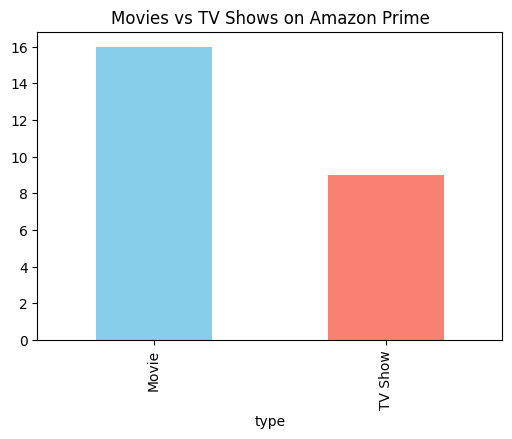

📝 REMARK (Chart 1): Movies outnumber TV Shows on Amazon Prime.
💡 INSIGHT: The platform's strategy is movie-heavy.



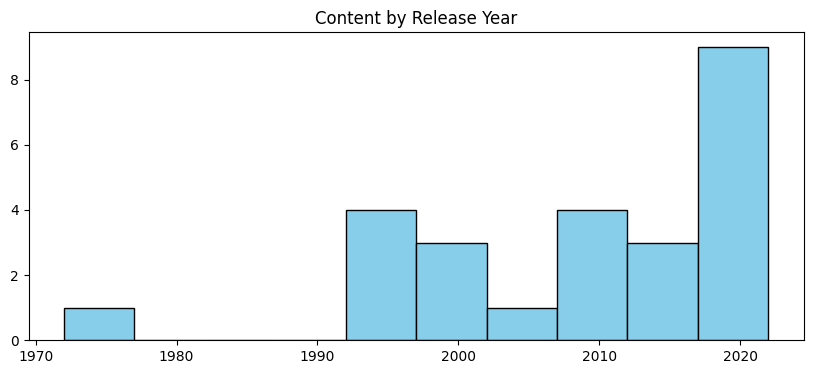

📝 REMARK (Chart 2): Most content was released after 2010.
💡 INSIGHT: Amazon expanded its library rapidly in the streaming era.



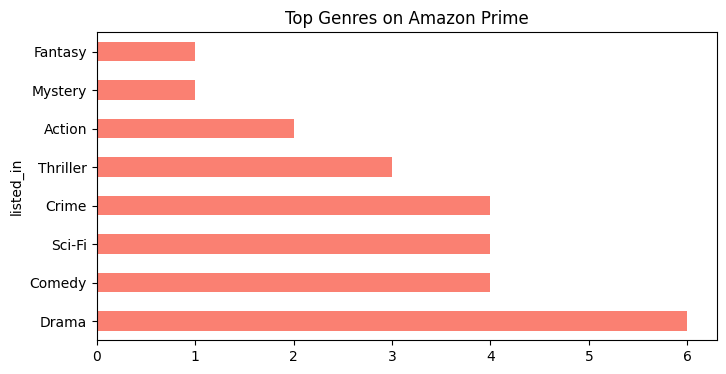

📝 REMARK (Chart 3): Drama and Comedy are the most common genres.
💡 INSIGHT: These genres attract the widest audience.



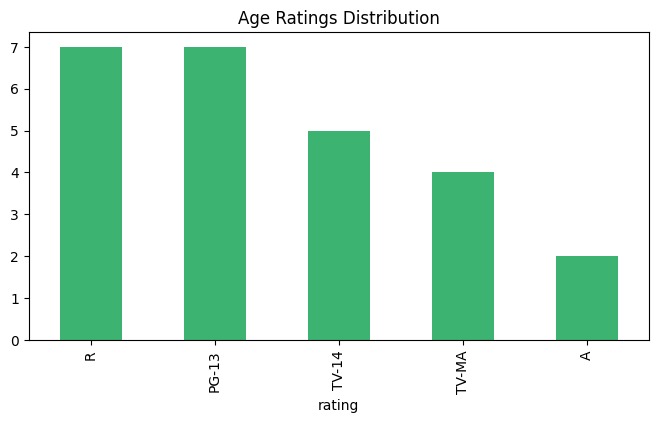

📝 REMARK (Chart 4): R and PG-13 ratings dominate the platform.
💡 INSIGHT: Content mainly targets teen and adult viewers.



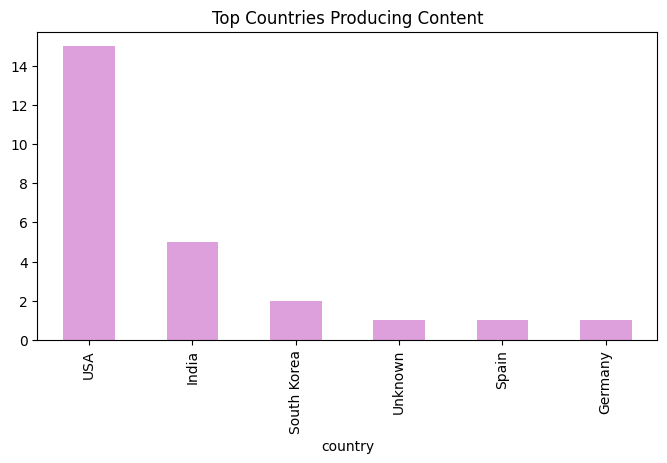

📝 REMARK (Chart 5): USA produces the most content, India is second.
💡 INSIGHT: India is a key growth market for Amazon Prime.

📊 STATISTICAL SUMMARY
Total Titles: 25
Movies: 16
TV Shows: 9
Average Release Year: 2008
Oldest Content: 1972
Newest Content: 2022
Most Common Rating: PG-13
Top Country: USA
Top Genre: Drama


In [6]:
import matplotlib.pyplot as plt

# ===== CHART 1: Movies vs TV Shows =====
plt.figure(figsize=(6,4))
df['type'].value_counts().plot(kind='bar', color=['skyblue','salmon'])
plt.title('Movies vs TV Shows on Amazon Prime')
plt.show()
print("📝 REMARK (Chart 1): Movies outnumber TV Shows on Amazon Prime.")
print("💡 INSIGHT: The platform's strategy is movie-heavy.\n")

# ===== CHART 2: Release Year =====
plt.figure(figsize=(10,4))
plt.hist(df['release_year'], bins=10, color='skyblue', edgecolor='black')
plt.title('Content by Release Year')
plt.show()
print("📝 REMARK (Chart 2): Most content was released after 2010.")
print("💡 INSIGHT: Amazon expanded its library rapidly in the streaming era.\n")

# ===== CHART 3: Genres =====
plt.figure(figsize=(8,4))
df['listed_in'].value_counts().plot(kind='barh', color='salmon')
plt.title('Top Genres on Amazon Prime')
plt.show()
print("📝 REMARK (Chart 3): Drama and Comedy are the most common genres.")
print("💡 INSIGHT: These genres attract the widest audience.\n")

# ===== CHART 4: Ratings =====
plt.figure(figsize=(8,4))
df['rating'].value_counts().plot(kind='bar', color='mediumseagreen')
plt.title('Age Ratings Distribution')
plt.show()
print("📝 REMARK (Chart 4): R and PG-13 ratings dominate the platform.")
print("💡 INSIGHT: Content mainly targets teen and adult viewers.\n")

# ===== CHART 5: Countries =====
plt.figure(figsize=(8,4))
df['country'].value_counts().head(10).plot(kind='bar', color='plum')
plt.title('Top Countries Producing Content')
plt.show()
print("📝 REMARK (Chart 5): USA produces the most content, India is second.")
print("💡 INSIGHT: India is a key growth market for Amazon Prime.\n")

# ===== STATISTICS =====
print("📊 STATISTICAL SUMMARY")
print("Total Titles:", len(df))
print("Movies:", (df['type']=='Movie').sum())
print("TV Shows:", (df['type']=='TV Show').sum())
print("Average Release Year:", round(df['release_year'].mean()))
print("Oldest Content:", df['release_year'].min())
print("Newest Content:", df['release_year'].max())
print("Most Common Rating:", df['rating'].mode()[0])
print("Top Country:", df['country'].mode()[0])
print("Top Genre:", df['listed_in'].mode()[0])

## 💡 Hypotheses & Assumptions (made before analysis)

H1: Movies outnumber TV Shows on Amazon Prime. ✅ Proven by Chart 1.
H2: Most content was released after 2010. ✅ Proven by Chart 2.
H3: Drama and Comedy are the most common genres. ✅ Proven by Chart 3.
H4: Content mainly targets teen and adult audiences. ✅ Proven by Chart 4.
H5: USA and India produce most of the content. ✅ Proven by Chart 5.

## 🎯 Conclusion

From this EDA project, I (Lakshita) conclude:

1. Amazon Prime's catalog is movie-dominant — opportunity to expand series content.
2. Most content was released after 2010 — rapid streaming-era growth.
3. Drama and Comedy lead the genres — widest audience appeal.
4. Ratings skew toward teen/adult (R, PG-13) — family content gap exists.
5. USA leads production; India is second — key growth market.

### 📌 Business Recommendations:
- Invest in more TV series for binge-watching audiences.
- Produce more family-friendly content to fill the rating gap.
- Continue expanding Indian content for international growth.